In [34]:
import pandas as pd
from pathlib import Path
import numpy as np
import random
import torch

SEED = 20260809
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path('/content')

train = pd.read_csv(DATA_DIR / 'train_labeled.csv')
validation = pd.read_csv(DATA_DIR / 'validation_labeled.csv', dtype={"query_id": str})
evaluation = pd.read_csv(DATA_DIR / 'evaluation_queries.csv', dtype={"query_id": str})

print(train.shape)
print(validation.shape)
print(evaluation.shape)

(120, 2)
(120, 3)
(120, 2)


In [35]:
print(train.columns)
print(validation.columns)
print(evaluation.columns)

Index(['text', 'intent'], dtype='object')
Index(['query_id', 'text', 'intent'], dtype='object')
Index(['query_id', 'text'], dtype='object')


In [36]:
print(train['intent'].nunique())
print(train['intent'].value_counts())
train

60
intent
qa_currency                 2
music_dislikeness           2
iot_coffee                  2
transport_ticket            2
iot_cleaning                2
email_sendemail             2
lists_createoradd           2
general_greet               2
recommendation_locations    2
cooking_query               2
takeaway_query              2
play_podcasts               2
weather_query               2
social_query                2
play_music                  2
transport_taxi              2
lists_query                 2
news_query                  2
qa_factoid                  2
qa_definition               2
alarm_remove                2
general_joke                2
social_post                 2
alarm_query                 2
iot_wemo_off                2
datetime_convert            2
recommendation_movies       2
email_addcontact            2
qa_maths                    2
audio_volume_up             2
iot_hue_lightchange         2
iot_hue_lighton             2
play_audiobook              2


,text,intent
0,каков долларовый эквивалент в песо,qa_currency
1,привет яндекс эта песня слишком шумная,music_dislikeness
2,сегодня,iot_coffee
3,купи мне билет на пять вечера в гатчину,transport_ticket
4,нужно ли подключать робот-пылесос к розетке,iot_cleaning
...,...,...
115,чашку кофе пожалуйста,iot_coffee
116,измени свет в моем доме на оранжевый,iot_hue_lightchange
117,установи будильник на среду в двенадцать часов...,alarm_set
118,давай сыграем в танки онлайн,play_game


In [37]:
import numpy as np
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
encoder = SentenceTransformer(MODEL_NAME, device='cpu')

def encode_text(text):
    return encoder.encode(text.tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True).astype('float32')

train_vectors = encode_text(train['text'])
validation_vectors = encode_text(validation['text'])
evaluation_vectors = encode_text(evaluation['text'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [38]:
print(train_vectors.shape)
print(validation_vectors.shape)
print(evaluation_vectors.shape)

(120, 384)
(120, 384)
(120, 384)


In [39]:
classes = sorted(train['intent'].unique())
intent_to_id = {intent: i for i, intent in enumerate(classes)}
id_to_intent = {i: intent for i, intent in enumerate(classes)}

y_train = train['intent'].map(intent_to_id).values
y_validation = validation['intent'].map(intent_to_id).values

for intent in y_train[:5]:
    print(intent, id_to_intent[intent])

print(y_train.shape)
print(y_validation.shape)

43 qa_currency
33 music_dislikeness
22 iot_coffee
57 transport_ticket
21 iot_cleaning
(120,)
(120,)


In [40]:
centroids = np.vstack([train_vectors[class_id == y_train].mean(axis=0) for class_id in range(len(classes))])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)

In [41]:
scores = validation_vectors @ centroids.T
pred = scores.argmax(axis=1)

acc_score = sum(pred == y_validation) / len(y_validation)
acc_score

np.float64(0.5416666666666666)

In [42]:
print(f"true labels: {y_validation[:5]}")
print(f"predicted labels: {pred[:5]}")

true labels: [40 48 40 48 10]
predicted labels: [35 59 35 48 11]


In [43]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

acc = accuracy_score(y_validation, pred)
f1 = f1_score(y_validation, pred, average='macro')

print(f"accuracy: {acc:.4f}")
print(f"f1 score: {f1:.4f}")

accuracy: 0.5417
f1 score: 0.4800


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
  def __init__(self, width, dropout=0.15):
    super().__init__()
    self.layers = nn.Sequential(
        nn.LayerNorm(width),
        nn.Linear(width, 2*width),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(2*width, width),
        nn.Dropout(dropout)
    )
  def forward(self, x):
    return F.gelu(x + self.layers(x))

class ResNetIntentClassifier(nn.Module):
  def __init__(self, input_size, number_of_classes, width=256, blocks=3, dropout=0.15):
    super().__init__()
    self.input_layers = nn.Sequential(nn.Linear(input_size, width), nn.GELU())
    self.blocks = nn.Sequential(*[ResidualBlock(width, dropout) for _ in range(blocks)])
    self.output_layers = nn.Linear(width, number_of_classes)
  def forward(self, x):
    x = self.input_layers(x)
    x = self.blocks(x)
    return self.output_layers(x)

model = ResNetIntentClassifier(train_vectors.shape[1], len(classes))
parameters = sum(parameter.numel() for parameter in model.parameters())

In [13]:
from torch.utils.data import DataLoader, Dataset

def run_experiment(width, blocks, dropout):
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)

  x_train_tensor = torch.tensor(train_vectors, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)
  x_val_tensor = torch.tensor(validation_vectors, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_validation, dtype=torch.long)

  train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
  train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(SEED))
  val_dataset = torch.utils.data.TensorDataset(x_val_tensor, y_val_tensor)
  val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

  model = ResNetIntentClassifier(train_vectors.shape[1], len(classes), width, blocks, dropout)
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

  NUM_EPOCH = 120
  history = []
  best_acc = -1
  best_f1 = -1
  best_epoch = 0
  epoch_without_improvement = 0

  for epoch in range(1, NUM_EPOCH+1):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in train_dataloader:
      optimizer.zero_grad()
      y_pred = model(x_batch)
      loss = loss_function(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item() * len(x_batch)

    predictions = []
    model.eval()
    with torch.no_grad():
      for x_batch, y_batch in val_dataloader:
        y_pred = model(x_batch)
        predictions.extend(y_pred.argmax(dim=1).tolist())

    train_loss = total_loss / len(train_dataset)
    acc = accuracy_score(y_validation, predictions)
    f1 = f1_score(y_validation, predictions, average='macro')
    history.append({
        'epoch': epoch,
        'loss': train_loss,
        'acc': acc,
        'f1': f1
        })
    print(f"epoch: {epoch}, loss: {train_loss:.4f}, acc: {acc:.4f}, f1: {f1:.4f}")
    if acc > best_acc:
      best_acc = acc
      best_f1 = f1
      best_epoch = epoch
      best_weights = {name: value.detach().clone() for name, value in model.state_dict().items()}
      epoch_without_improvement = 0
    else:
      epoch_without_improvement += 1
    if epoch_without_improvement >= 15:
      print("Early stopping")
      break

  model.load_state_dict(best_weights)
  history = pd.DataFrame(history)
  print(f"Лучшая точность валидации: {best_acc:.3f}")
  print(f"Лучшая эпоха: {int(history.loc[history['acc'].idxmax(), 'epoch'])}")
  return width, blocks, dropout, best_acc, best_f1, best_epoch, history

In [14]:
width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment(256, 3, 0.15)
print(f'{width=} {blocks=} {dropout=} {best_acc=:.4f} {best_f1=:.4f} {best_epoch=}')

epoch: 1, loss: 4.1265, acc: 0.0500, f1: 0.0252
epoch: 2, loss: 4.0231, acc: 0.1083, f1: 0.0652
epoch: 3, loss: 3.9651, acc: 0.1583, f1: 0.1151
epoch: 4, loss: 3.8623, acc: 0.2250, f1: 0.1800
epoch: 5, loss: 3.7223, acc: 0.2417, f1: 0.1985
epoch: 6, loss: 3.5657, acc: 0.2667, f1: 0.2228
epoch: 7, loss: 3.3711, acc: 0.2833, f1: 0.2349
epoch: 8, loss: 3.1445, acc: 0.3417, f1: 0.3005
epoch: 9, loss: 2.7902, acc: 0.4250, f1: 0.3764
epoch: 10, loss: 2.3907, acc: 0.4583, f1: 0.4033
epoch: 11, loss: 2.0206, acc: 0.4500, f1: 0.3971
epoch: 12, loss: 1.5807, acc: 0.4583, f1: 0.4008
epoch: 13, loss: 1.2661, acc: 0.4667, f1: 0.3974
epoch: 14, loss: 0.9483, acc: 0.5000, f1: 0.4465
epoch: 15, loss: 0.6502, acc: 0.5000, f1: 0.4496
epoch: 16, loss: 0.5121, acc: 0.5083, f1: 0.4658
epoch: 17, loss: 0.4162, acc: 0.5167, f1: 0.4748
epoch: 18, loss: 0.2830, acc: 0.5250, f1: 0.4857
epoch: 19, loss: 0.2113, acc: 0.5250, f1: 0.4821
epoch: 20, loss: 0.1731, acc: 0.5417, f1: 0.5004
epoch: 21, loss: 0.1274, acc:

In [15]:
width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment(128, 3, 0.15)
print(f'{width=} {blocks=} {dropout=} {best_acc=:.4f} {best_f1=:.4f} {best_epoch=}')

epoch: 1, loss: 4.1074, acc: 0.0333, f1: 0.0127
epoch: 2, loss: 4.0601, acc: 0.0583, f1: 0.0353
epoch: 3, loss: 4.0189, acc: 0.1083, f1: 0.0812
epoch: 4, loss: 3.9888, acc: 0.1583, f1: 0.1121
epoch: 5, loss: 3.9499, acc: 0.1917, f1: 0.1155
epoch: 6, loss: 3.9101, acc: 0.1917, f1: 0.1211
epoch: 7, loss: 3.8486, acc: 0.2333, f1: 0.1636
epoch: 8, loss: 3.7726, acc: 0.2500, f1: 0.1757
epoch: 9, loss: 3.7004, acc: 0.2417, f1: 0.1721
epoch: 10, loss: 3.6146, acc: 0.2750, f1: 0.2147
epoch: 11, loss: 3.5283, acc: 0.3000, f1: 0.2479
epoch: 12, loss: 3.4055, acc: 0.3083, f1: 0.2612
epoch: 13, loss: 3.2417, acc: 0.3333, f1: 0.2775
epoch: 14, loss: 3.1257, acc: 0.3250, f1: 0.2761
epoch: 15, loss: 2.9217, acc: 0.3167, f1: 0.2750
epoch: 16, loss: 2.7569, acc: 0.3583, f1: 0.3097
epoch: 17, loss: 2.5927, acc: 0.3917, f1: 0.3420
epoch: 18, loss: 2.3640, acc: 0.3917, f1: 0.3386
epoch: 19, loss: 2.1523, acc: 0.4167, f1: 0.3524
epoch: 20, loss: 1.9448, acc: 0.4250, f1: 0.3679
epoch: 21, loss: 1.7599, acc:

In [16]:
width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment(512, 3, 0.15)
print(f'{width=} {blocks=} {dropout=} {best_acc=:.4f} {best_f1=:.4f} {best_epoch=}')

epoch: 1, loss: 4.1377, acc: 0.0500, f1: 0.0189
epoch: 2, loss: 3.9665, acc: 0.2250, f1: 0.1751
epoch: 3, loss: 3.7584, acc: 0.3667, f1: 0.2949
epoch: 4, loss: 3.4155, acc: 0.3333, f1: 0.2687
epoch: 5, loss: 2.9348, acc: 0.4000, f1: 0.3233
epoch: 6, loss: 2.3214, acc: 0.4333, f1: 0.3570
epoch: 7, loss: 1.6178, acc: 0.5000, f1: 0.4446
epoch: 8, loss: 0.9752, acc: 0.5333, f1: 0.4765
epoch: 9, loss: 0.5685, acc: 0.5000, f1: 0.4389
epoch: 10, loss: 0.3162, acc: 0.5167, f1: 0.4665
epoch: 11, loss: 0.1731, acc: 0.4833, f1: 0.4304
epoch: 12, loss: 0.1307, acc: 0.4917, f1: 0.4417
epoch: 13, loss: 0.0711, acc: 0.4833, f1: 0.4311
epoch: 14, loss: 0.0471, acc: 0.5417, f1: 0.4865
epoch: 15, loss: 0.0338, acc: 0.5333, f1: 0.4759
epoch: 16, loss: 0.0251, acc: 0.5167, f1: 0.4628
epoch: 17, loss: 0.0174, acc: 0.5000, f1: 0.4519
epoch: 18, loss: 0.0122, acc: 0.4917, f1: 0.4425
epoch: 19, loss: 0.0118, acc: 0.4833, f1: 0.4280
epoch: 20, loss: 0.0102, acc: 0.5000, f1: 0.4517
epoch: 21, loss: 0.0087, acc:

In [17]:
width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment(256, 5, 0.15)
print(f'{width=} {blocks=} {dropout=} {best_acc=:.4f} {best_f1=:.4f} {best_epoch=}')

epoch: 1, loss: 4.1006, acc: 0.0583, f1: 0.0298
epoch: 2, loss: 4.0484, acc: 0.0583, f1: 0.0291
epoch: 3, loss: 3.9965, acc: 0.1417, f1: 0.1000
epoch: 4, loss: 3.9038, acc: 0.1750, f1: 0.1066
epoch: 5, loss: 3.7860, acc: 0.1917, f1: 0.1176
epoch: 6, loss: 3.6212, acc: 0.2000, f1: 0.1436
epoch: 7, loss: 3.4012, acc: 0.2583, f1: 0.1853
epoch: 8, loss: 3.1611, acc: 0.2833, f1: 0.2092
epoch: 9, loss: 2.8273, acc: 0.3000, f1: 0.2252
epoch: 10, loss: 2.4803, acc: 0.3500, f1: 0.2726
epoch: 11, loss: 2.0451, acc: 0.4000, f1: 0.3327
epoch: 12, loss: 1.6323, acc: 0.4167, f1: 0.3774
epoch: 13, loss: 1.3044, acc: 0.4667, f1: 0.4120
epoch: 14, loss: 0.9287, acc: 0.5250, f1: 0.4529
epoch: 15, loss: 0.7631, acc: 0.4917, f1: 0.4344
epoch: 16, loss: 0.5025, acc: 0.5250, f1: 0.4746
epoch: 17, loss: 0.4001, acc: 0.5083, f1: 0.4600
epoch: 18, loss: 0.2936, acc: 0.4833, f1: 0.4242
epoch: 19, loss: 0.2357, acc: 0.4917, f1: 0.4207
epoch: 20, loss: 0.2030, acc: 0.4833, f1: 0.4299
epoch: 21, loss: 0.1340, acc:

In [18]:
width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment(256, 3, 0.3)
print(f'{width=} {blocks=} {dropout=} {best_acc=:.4f} {best_f1=:.4f} {best_epoch=}')

epoch: 1, loss: 4.1110, acc: 0.0417, f1: 0.0205
epoch: 2, loss: 4.0645, acc: 0.0500, f1: 0.0253
epoch: 3, loss: 4.0418, acc: 0.0583, f1: 0.0282
epoch: 4, loss: 4.0006, acc: 0.0917, f1: 0.0492
epoch: 5, loss: 3.9790, acc: 0.1583, f1: 0.1236
epoch: 6, loss: 3.9122, acc: 0.1500, f1: 0.1072
epoch: 7, loss: 3.8206, acc: 0.2167, f1: 0.1693
epoch: 8, loss: 3.7693, acc: 0.2417, f1: 0.1725
epoch: 9, loss: 3.6607, acc: 0.2833, f1: 0.2241
epoch: 10, loss: 3.5072, acc: 0.3000, f1: 0.2337
epoch: 11, loss: 3.3339, acc: 0.3333, f1: 0.2630
epoch: 12, loss: 3.1285, acc: 0.3667, f1: 0.2971
epoch: 13, loss: 2.9299, acc: 0.3667, f1: 0.2960
epoch: 14, loss: 2.6313, acc: 0.3667, f1: 0.3031
epoch: 15, loss: 2.2472, acc: 0.3917, f1: 0.3255
epoch: 16, loss: 2.0528, acc: 0.3917, f1: 0.3246
epoch: 17, loss: 1.8100, acc: 0.4250, f1: 0.3714
epoch: 18, loss: 1.4471, acc: 0.4500, f1: 0.3914
epoch: 19, loss: 1.2738, acc: 0.4500, f1: 0.3949
epoch: 20, loss: 1.0539, acc: 0.4667, f1: 0.4097
epoch: 21, loss: 0.8537, acc:

In [45]:
x_train_tensor = torch.tensor(train_vectors, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_val_tensor = torch.tensor(validation_vectors, dtype=torch.float32)
y_val_tensor = torch.tensor(y_validation, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = torch.utils.data.TensorDataset(x_val_tensor, y_val_tensor)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [46]:
model = ResNetIntentClassifier(train_vectors.shape[1], len(classes))
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

NUM_EPOCH = 120
history = []
best_acc = -1
best_epoch = 0
epoch_without_improvement = 0

for epoch in range(1, NUM_EPOCH+1):
  model.train()
  total_loss = 0.0
  for x_batch, y_batch in train_dataloader:
    optimizer.zero_grad()
    y_pred = model(x_batch)
    loss = loss_function(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * len(x_batch)

  predictions = []
  model.eval()
  with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
      y_pred = model(x_batch)
      predictions.extend(y_pred.argmax(dim=1).tolist())

  train_loss = total_loss / len(train_dataset)
  acc = accuracy_score(y_validation, predictions)
  f1 = f1_score(y_validation, predictions, average='macro')
  history.append({
      'epoch': epoch,
      'loss': train_loss,
      'acc': acc,
      'f1': f1
      })
  print(f"epoch: {epoch}, loss: {train_loss:.4f}, acc: {acc:.4f}, f1: {f1:.4f}")
  if acc > best_acc:
    best_acc = acc
    best_epoch = epoch
    best_weights = {name: value.detach().clone() for name, value in model.state_dict().items()}
    epoch_without_improvement = 0
  else:
    epoch_without_improvement += 1
  if epoch_without_improvement >= 15:
    print("Early stopping")
    break

model.load_state_dict(best_weights)
history = pd.DataFrame(history)
print(f"Лучшая точность валидации: {best_acc:.3f}")
print(f"Лучшая эпоха: {int(history.loc[history['acc'].idxmax(), 'epoch'])}")

epoch: 1, loss: 4.1042, acc: 0.0583, f1: 0.0257
epoch: 2, loss: 4.0171, acc: 0.1000, f1: 0.0528
epoch: 3, loss: 3.9434, acc: 0.3083, f1: 0.2317
epoch: 4, loss: 3.8445, acc: 0.3333, f1: 0.2615
epoch: 5, loss: 3.6999, acc: 0.3917, f1: 0.3199
epoch: 6, loss: 3.5328, acc: 0.4083, f1: 0.3442
epoch: 7, loss: 3.3309, acc: 0.4500, f1: 0.3908
epoch: 8, loss: 3.0652, acc: 0.4583, f1: 0.3815
epoch: 9, loss: 2.7432, acc: 0.4833, f1: 0.4072
epoch: 10, loss: 2.4079, acc: 0.4833, f1: 0.4062
epoch: 11, loss: 2.0164, acc: 0.4667, f1: 0.3996
epoch: 12, loss: 1.6194, acc: 0.4917, f1: 0.4278
epoch: 13, loss: 1.3202, acc: 0.5000, f1: 0.4464
epoch: 14, loss: 0.9593, acc: 0.5083, f1: 0.4530
epoch: 15, loss: 0.7672, acc: 0.4917, f1: 0.4342
epoch: 16, loss: 0.5679, acc: 0.5250, f1: 0.4661
epoch: 17, loss: 0.4361, acc: 0.5250, f1: 0.4771
epoch: 18, loss: 0.3421, acc: 0.5417, f1: 0.4951
epoch: 19, loss: 0.2555, acc: 0.5333, f1: 0.4913
epoch: 20, loss: 0.1716, acc: 0.5083, f1: 0.4555
epoch: 21, loss: 0.1461, acc:

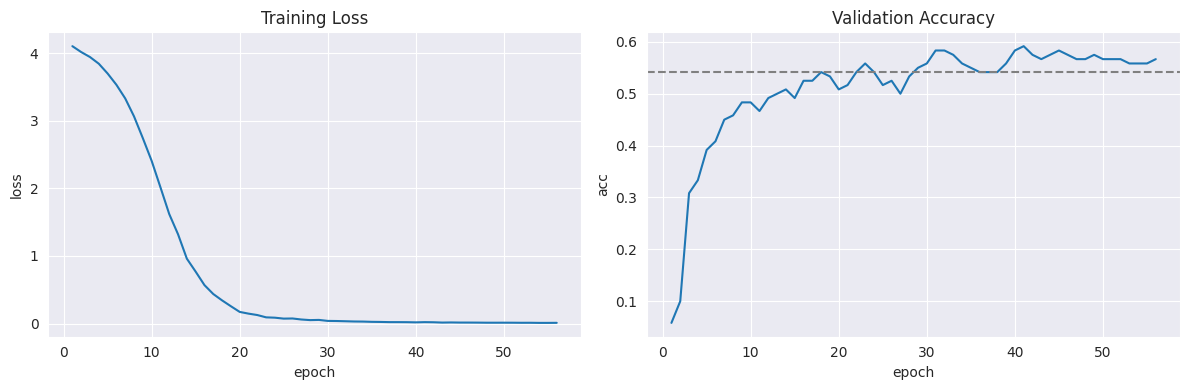

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(x='epoch', y='loss', data=history, ax=axes[0])
axes[0].set_title('Training Loss')
sns.lineplot(x='epoch', y='acc', data=history, ax=axes[1])
axes[1].axhline(acc_score, color='grey', linestyle='--')
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
plt.show()

In [48]:
model.eval()
predictions = []
with torch.no_grad():
  for x_batch, y_batch in val_dataloader:
    y_pred = model(x_batch)
    predictions.extend(y_pred.argmax(dim=1).tolist())

acc = accuracy_score(y_validation, predictions)
f1 = f1_score(y_validation, predictions, average='macro')
print(f"accuracy: {acc:.3f}")
print(f"f1 score: {f1:.3f}")

accuracy: 0.592
f1 score: 0.536


In [49]:
validation_analysis = validation[['text', 'intent']].copy()
validation_analysis['predicted_intent'] = [id_to_intent[i] for i in predictions]
errors = validation_analysis[validation_analysis['intent'] != validation_analysis['predicted_intent']]
print(f"Количество ошибок: {len(errors)} из {len(validation)}")

errors

Количество ошибок: 49 из 120


,text,intent,predicted_intent
0,пожалуйста ставь только грустную музыку на плеере,play_music,music_query
1,соревнования по бегу в приморском районе,recommendation_events,recommendation_locations
2,я хочу послушать песни группы сплин пожалуйста...,play_music,music_query
5,что мне нужно сделать завтра,calendar_query,calendar_set
8,я не мог расслышать повтори это громче,audio_volume_up,music_dislikeness
11,instagram,social_query,social_post
12,покажи мне номер службы поддержки клиентов mcd...,social_post,email_query
18,прибавь громкость пожалуйста,audio_volume_other,audio_volume_up
20,убери будильник на семь тридцать утра в понеде...,alarm_remove,alarm_set
23,пожалуйста будь тихим на следующие два часа,audio_volume_mute,audio_volume_down


In [50]:
evaluation_loader = DataLoader(torch.tensor(evaluation_vectors, dtype=torch.float32), batch_size=32, shuffle=False)

model.eval()
predictions = []
with torch.no_grad():
  for x_batch in evaluation_loader:
    y_pred = model(x_batch)
    predictions.extend(y_pred.argmax(dim=1).tolist())

evaluation['intent'] = [id_to_intent[i] for i in predictions]

intend_predictions = pd.DataFrame({
    'query_id': evaluation['query_id'],
    'intent': evaluation['intent']
})

intend_predictions.to_csv('intend_predictions.csv', index=False)
intend_predictions

,query_id,intent
0,0001,play_game
1,0002,iot_hue_lighton
2,0003,calendar_query
3,0004,iot_wemo_on
4,0005,iot_cleaning
...,...,...
115,0116,recommendation_locations
116,0117,qa_currency
117,0118,general_greet
118,0119,play_game


Из вариантов с максимальной Accuracy 0.5667 выбрана конфигурация (256, 3, 0.15), поскольку её Macro F1 среди них наибольший

In [68]:
extra_train = validation.groupby('intent').sample(n=1, random_state=SEED)

new_train = pd.concat([train, extra_train[['text', 'intent']]], ignore_index=True)
new_validation = (validation.drop(extra_train.index)[['query_id', 'text', 'intent']].reset_index(drop=True))

print(new_train.shape)
print(new_validation.shape)

(180, 2)
(60, 3)


In [70]:
new_train_vectors = encode_text(new_train['text'])
new_validation_vectors = encode_text(new_validation['text'])
new_train_vectors.shape, new_validation_vectors.shape

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

((180, 384), (60, 384))

In [75]:
new_y_train = new_train['intent'].map(intent_to_id).values
new_y_validation = new_validation['intent'].map(intent_to_id).values
new_y_train.shape, new_y_validation.shape

((180,), (60,))

In [81]:
new_centroids = np.vstack([new_train_vectors[class_id == new_y_train].mean(axis=0) for class_id in range(len(classes))])
new_centroids /= np.linalg.norm(new_centroids, axis=1, keepdims=True)

new_scores = new_validation_vectors @ new_centroids.T
new_pred = new_scores.argmax(axis=1)

new_acc_score = sum(new_pred == new_y_validation) / len(new_y_validation)
new_f1_score = f1_score(new_y_validation, new_pred, average='macro')
new_acc_score, new_f1_score

(np.float64(0.6), 0.5305555555555556)

In [82]:
from torch.utils.data import DataLoader, Dataset

def run_experiment_extra(width, blocks, dropout):
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)

  x_train_tensor = torch.tensor(new_train_vectors, dtype=torch.float32)
  y_train_tensor = torch.tensor(new_y_train, dtype=torch.long)
  x_val_tensor = torch.tensor(new_validation_vectors, dtype=torch.float32)
  y_val_tensor = torch.tensor(new_y_validation, dtype=torch.long)

  train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
  train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(SEED))
  val_dataset = torch.utils.data.TensorDataset(x_val_tensor, y_val_tensor)
  val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

  model = ResNetIntentClassifier(new_train_vectors.shape[1], len(classes), width, blocks, dropout)
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

  NUM_EPOCH = 120
  history = []
  best_acc = -1
  best_f1 = -1
  best_epoch = 0
  epoch_without_improvement = 0

  for epoch in range(1, NUM_EPOCH+1):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in train_dataloader:
      optimizer.zero_grad()
      y_pred = model(x_batch)
      loss = loss_function(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item() * len(x_batch)

    predictions = []
    model.eval()
    with torch.no_grad():
      for x_batch, y_batch in val_dataloader:
        y_pred = model(x_batch)
        predictions.extend(y_pred.argmax(dim=1).tolist())

    train_loss = total_loss / len(train_dataset)
    acc = accuracy_score(new_y_validation, predictions)
    f1 = f1_score(new_y_validation, predictions, average='macro')
    history.append({
        'epoch': epoch,
        'loss': train_loss,
        'acc': acc,
        'f1': f1
        })
    print(f"epoch: {epoch}, loss: {train_loss:.4f}, acc: {acc:.4f}, f1: {f1:.4f}")
    if acc > best_acc:
      best_acc = acc
      best_f1 = f1
      best_epoch = epoch
      best_weights = {name: value.detach().clone() for name, value in model.state_dict().items()}
      epoch_without_improvement = 0
    else:
      epoch_without_improvement += 1
    if epoch_without_improvement >= 15:
      print("Early stopping")
      break

  model.load_state_dict(best_weights)
  history = pd.DataFrame(history)
  print(f"Лучшая точность валидации: {best_acc:.3f}")
  print(f"Лучшая эпоха: {int(history.loc[history['acc'].idxmax(), 'epoch'])}")

  evaluation_loader = DataLoader(torch.tensor(evaluation_vectors, dtype=torch.float32), batch_size=32, shuffle=False)

  model.eval()
  predictions = []
  with torch.no_grad():
    for x_batch in evaluation_loader:
      y_pred = model(x_batch)
      predictions.extend(y_pred.argmax(dim=1).tolist())

  evaluation['intent'] = [id_to_intent[i] for i in predictions]

  intent_predictions = pd.DataFrame({
      'query_id': evaluation['query_id'],
      'intent': evaluation['intent']
  })

  intent_predictions.to_csv('intent_new_predictions.csv', index=False)

  return width, blocks, dropout, best_acc, best_f1, best_epoch, history

width, blocks, dropout, best_acc, best_f1, best_epoch, history = run_experiment_extra(256, 3, 0.15)

epoch: 1, loss: 4.1103, acc: 0.0833, f1: 0.0313
epoch: 2, loss: 4.0016, acc: 0.1667, f1: 0.1011
epoch: 3, loss: 3.8884, acc: 0.2333, f1: 0.1512
epoch: 4, loss: 3.7194, acc: 0.3000, f1: 0.2279
epoch: 5, loss: 3.4907, acc: 0.3000, f1: 0.2296
epoch: 6, loss: 3.1776, acc: 0.3333, f1: 0.2675
epoch: 7, loss: 2.7177, acc: 0.4000, f1: 0.3289
epoch: 8, loss: 2.2592, acc: 0.4333, f1: 0.3467
epoch: 9, loss: 1.7301, acc: 0.4833, f1: 0.4094
epoch: 10, loss: 1.2059, acc: 0.5833, f1: 0.5111
epoch: 11, loss: 0.8541, acc: 0.5500, f1: 0.4667
epoch: 12, loss: 0.6080, acc: 0.6167, f1: 0.5206
epoch: 13, loss: 0.4237, acc: 0.5833, f1: 0.5111
epoch: 14, loss: 0.3241, acc: 0.5833, f1: 0.5067
epoch: 15, loss: 0.2449, acc: 0.5667, f1: 0.4956
epoch: 16, loss: 0.1879, acc: 0.6000, f1: 0.5233
epoch: 17, loss: 0.1489, acc: 0.6000, f1: 0.5317
epoch: 18, loss: 0.1314, acc: 0.5667, f1: 0.5083
epoch: 19, loss: 0.1051, acc: 0.6167, f1: 0.5361
epoch: 20, loss: 0.0905, acc: 0.6167, f1: 0.5472
epoch: 21, loss: 0.0699, acc:

После переноса по одному запросу каждого интента обучение выросло со 120 до 180 строк, а валидация сократилась со 120 до 60. На этой новой валидации ResNet обошла центроиды по обеим метрикам. Сравнивать её 0.6333 напрямую с прежней Accuracy 0.5667 нельзя: состав и размер валидации изменились.